In [1]:
# Thư viện xử lý dữ liệu
import pandas as pd
import numpy as np
# Thư viện Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Thư viện visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Tải dữ liệu từ sklearn
iris = load_iris()
# Tạo DataFrame để dễ xử lý
df = pd.DataFrame(
data=iris.data,
columns=iris.feature_names
)
df['target'] = iris.target
df['species'] = df['target'].map({
0: 'setosa',
1: 'versicolor',
2: 'virginica'
})
# Xem thông tin cơ bản
print(df.head())
print(df.info())
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target  

In [3]:
# Tách features và target
X = df[['sepal length (cm)', 'sepal width (cm)',
'petal length (cm)', 'petal width (cm)']]
y = df['target']
# Hoặc sử dụng trực tiếp từ iris object
X = iris.data
y = iris.target
print(f"Shape của X: {X.shape}")
print(f"Shape của y: {y.shape}")

Shape của X: (150, 4)
Shape của y: (150,)


In [4]:
# Phân chia Train/Test

# Chia dữ liệu 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Đảm bảo tỷ lệ các lớp đồng đều
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Train set: (105, 4)
Test set: (45, 4)


In [5]:
# Khởi tạo StandardScaler
scaler = StandardScaler()
# Fit trên train set và transform cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Kiểm tra mean và std sau chuẩn hóa
print("Mean sau scaling:",
X_train_scaled.mean(axis=0))
print("Std sau scaling:", X_train_scaled.std(axis=0))

Mean sau scaling: [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]
Std sau scaling: [1. 1. 1. 1.]


In [6]:
# Tạo mô hình Logistic Regression
model = LogisticRegression(
multi_class='multinomial', # Cho phân loại đa lớp
solver='lbfgs',
# Thuật toán tối ưu
max_iter=1000,
# Số iterations tối đa
random_state=42
# Reproducibility
)

In [7]:
# Huấn luyện mô hình
model.fit(X_train_scaled, y_train)

# Dự đoán trên tập test
y_pred = model.predict(X_test_scaled)

# Dự đoán xác suất cho mỗi lớp
y_pred_proba = model.predict_proba(X_test_scaled)

print("Dự đoán (5 mẫu đầu):", y_pred[:5])
print("Xác suất (5 mẫu đầu):")
print(y_pred_proba[:5])


Dự đoán (5 mẫu đầu): [2 1 1 1 2]
Xác suất (5 mẫu đầu):
[[3.28358312e-05 1.01448072e-01 8.98519092e-01]
 [1.41182995e-02 7.89437074e-01 1.96444626e-01]
 [3.58121931e-03 6.20192330e-01 3.76226450e-01]
 [2.18102444e-02 6.29198388e-01 3.48991368e-01]
 [5.15171433e-03 3.84550988e-01 6.10297298e-01]]


/home/vophilong/Documents/BTap_DeepLearning/BaiTapDeepLearning/deep_learning/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [9]:
# Tính accuracy
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Hoặc sử dụng accuracy_score
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")



Train Accuracy: 0.9810
Test Accuracy: 0.9111
Accuracy: 0.9111


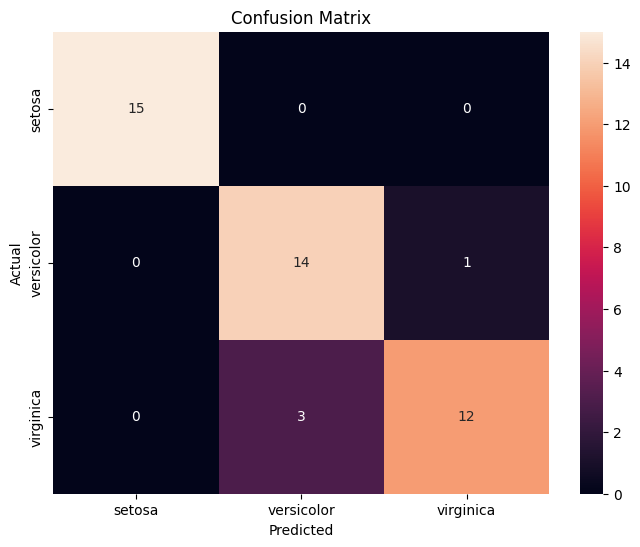

In [10]:
# Ma trận nhầm lẫn
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:

# Báo cáo chi tiết
from sklearn.metrics import classification_report
report = classification_report(
    y_test, y_pred,
    target_names=iris.target_names
)
print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



/home/vophilong/Documents/BTap_DeepLearning/BaiTapDeepLearning/deep_learning/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


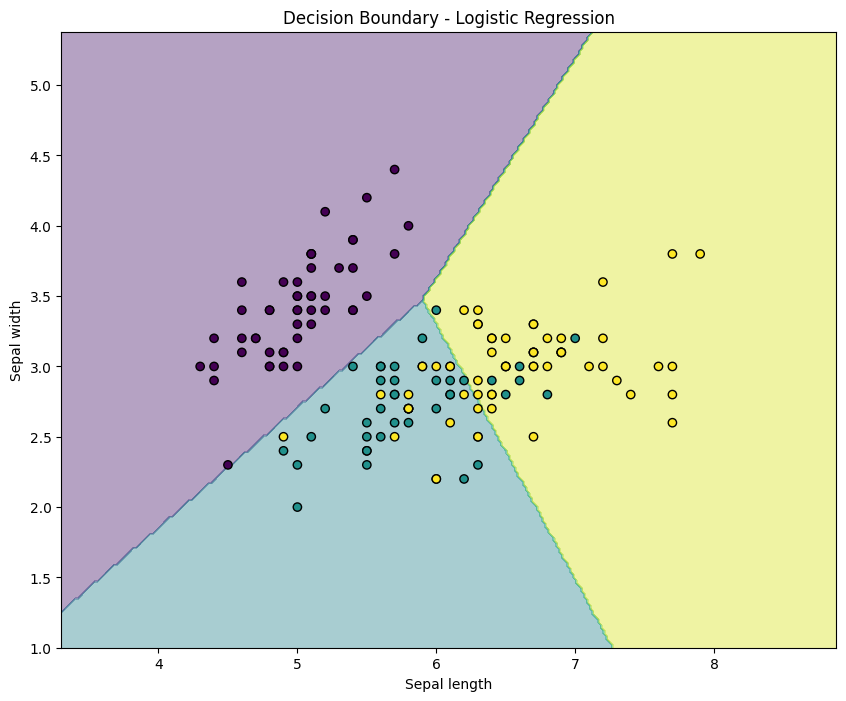

In [12]:
# Chỉ sử dụng 2 đặc trưng đầu để dễ visualize
X_2d = iris.data[:, :2]
y = iris.target
# Train lại với 2 features
model_2d = LogisticRegression(multi_class='multinomial', solver='lbfgs')
model_2d.fit(X_2d, y)
# Tạo lưới điểm để vẽ boundary
h = 0.02
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Decision Boundary - Logistic Regression')
plt.show()